## STAT/SDST3612: Statistical Machine Learning
### Assignment 2: Classification
### DUE: Nov 2, 2025, Sunday, 11:59 PM

In [2]:
! pip install numpy pandas matplotlib scikit-learn keras TensorFlow

In [3]:
# Q7
# load mnist dataset
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

# if keras.datasets causes issues, you may install TensorFlow and import from tensorflow.keras.datasets

X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
y_train shape: (60000,)
y_test shape: (10000,)


In [4]:
# Q7 (a)

# ------------------
# Write your code here

import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
import matplotlib.pyplot as plt

# data preprocessing: flatten and standardize the data
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

print('Data preprocessing completed.')
print('X_train_scaled shape:', X_train_flat.shape)
print('X_test_scaled shape:', X_test_flat.shape)


# create and train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_flat, y_train)

y_pred = lda.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {accuracy:.4f}")

# ------------------

Data preprocessing completed.
X_train_scaled shape: (60000, 784)
X_test_scaled shape: (10000, 784)
Testing Accuracy: 0.8730


In [7]:
# Q7 (b)

# ------------------
# Write your code here

# filter the data with label 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_binary = X_train_scaled[train_mask]
y_train_binary = y_train[train_mask]
X_test_binary = X_test_scaled[test_mask]
y_test_binary = y_test[test_mask]

print(f"Binary training set size: {X_train_binary.shape[0]}")
print(f"Binary testing set size: {X_test_binary.shape[0]}")

# set up and train the LDA model
lda_binary = LinearDiscriminantAnalysis()
lda_binary.fit(X_train_binary, y_train_binary)

# prediction
y_pred_binary = lda_binary.predict(X_test_binary)

recall = recall_score(y_test_binary, y_pred_binary, pos_label=1)
precision = precision_score(y_test_binary, y_pred_binary, pos_label=1)
f1 = f1_score(y_test_binary, y_pred_binary, pos_label=1)

print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")

# ------------------

Binary training set size: 12665
Binary testing set size: 2115
Recall: 0.9938
Precision: 0.9965
F1-Score: 0.9951


In [1]:
# Q8
# load cifar10 dataset
from keras.datasets import cifar10
from sklearn.preprocessing import StandardScaler

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train_flat = X_train.reshape(X_train.shape[0], -1).astype('float32')
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype('float32')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# 2D --> 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# if keras.datasets causes issues, you may install TensorFlow and import from tensorflow.keras.datasets

X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000, 1)
y_test shape: (10000, 1)


Consider flatten the images to 1D vectors and make the shape of the X be (Batch, dim).

In [4]:
# Q8 (a)

# ------------------
# Write your code here

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
import numpy as np

print('Flattened X_train shape:', X_train_flat.shape)
print('Flattened X_test shape:', X_test_flat.shape)

# saga supports L1 penalty
softmax_l1 = LogisticRegression(multi_class='multinomial', solver='saga', penalty='l1', C=1.0, max_iter=10, random_state=42)


# use less data to save time
sample_size = 5000
indices = np.random.choice(len(X_train_flat), sample_size, replace=False)
X_sample = X_train_flat[indices]
y_sample = y_train[indices]


softmax_l1.fit(X_train_flat, y_train)

# evaluation
train_score = softmax_l1.score(X_train_flat, y_train)
test_score = softmax_l1.score(X_test_flat, y_test)

print(f"Training accuracy (on sample): {train_score:.4f}")
print(f"Test accuracy: {test_score:.4f}")
print(f"Number of iterations: {softmax_l1.n_iter_}")
# ------------------

Flattened X_train shape: (50000, 3072)
Flattened X_test shape: (10000, 3072)
Training accuracy (on sample): 0.4448
Test accuracy: 0.4061
Number of iterations: [10]


Start training: (epochs=30, lr=0.01, lambda=0.0001, reg_type=l1)
Epoch 1/30 - Loss: 1.8246
Epoch 2/30 - Loss: 1.7637
Epoch 3/30 - Loss: 1.7657
Epoch 4/30 - Loss: 1.7581
Epoch 5/30 - Loss: 1.7288
Epoch 6/30 - Loss: 1.7404
Epoch 7/30 - Loss: 1.7382
Epoch 8/30 - Loss: 1.6990
Epoch 9/30 - Loss: 1.7089
Epoch 10/30 - Loss: 1.7066
Epoch 11/30 - Loss: 1.7004
Epoch 12/30 - Loss: 1.6950
Epoch 13/30 - Loss: 1.7011
Epoch 14/30 - Loss: 1.7089
Epoch 15/30 - Loss: 1.7033
Epoch 16/30 - Loss: 1.7031
Epoch 17/30 - Loss: 1.6756
Epoch 18/30 - Loss: 1.6720
Epoch 19/30 - Loss: 1.6808
Epoch 20/30 - Loss: 1.7231
Epoch 21/30 - Loss: 1.6991
Epoch 22/30 - Loss: 1.6858
Epoch 23/30 - Loss: 1.6785
Epoch 24/30 - Loss: 1.7174
Epoch 25/30 - Loss: 1.6864
Epoch 26/30 - Loss: 1.6632
Epoch 27/30 - Loss: 1.6750
Epoch 28/30 - Loss: 1.6753
Epoch 29/30 - Loss: 1.6878
Epoch 30/30 - Loss: 1.6772
Training completed.
Test set accuracy: 39.16%
Calculating accuracy for each class:
 - Class 0 (airplane): 0.5750 (575/1000)
 - Class 1

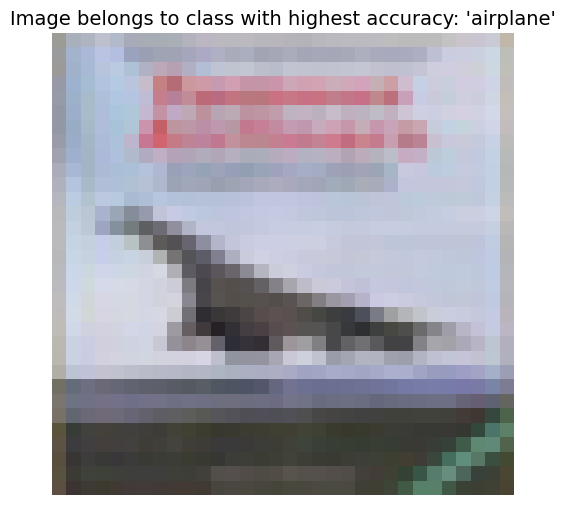

In [3]:
# Q8 (b)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from keras.datasets import cifar10

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

y_train_one_hot = to_categorical(y_train, 10)
cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                  'dog', 'frog', 'horse', 'ship', 'truck']

class SoftmaxRegression:
    def __init__(self, input_dim, output_dim, lambda_reg=0.001, reg_type='l2'):
        self.W = np.random.randn(output_dim, input_dim) * 0.01  # (10, 3072)
        self.b = np.zeros((output_dim, 1))  # (10, 1)
        self.lambda_reg = lambda_reg
        self.reg_type = reg_type
    
    def _softmax(self, z):
        z_stable = z - np.max(z, axis=0, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
    
    def compute_loss(self, X_T, y_T):
        # X_T: (features, N), y_T: (classes, N)
        n_samples = X_T.shape[1]
        
        z = self.W @ X_T + self.b
        y_pred = self._softmax(z)
        
        cross_entropy_loss = -np.sum(y_T * np.log(y_pred + 1e-9)) / n_samples
        
        if self.reg_type == 'l1':
            # L1 regularization
            reg_penalty = self.lambda_reg * np.sum(np.abs(self.W))
        elif self.reg_type == 'l2':
            # L2 regularization
            reg_penalty = (self.lambda_reg / 2) * np.sum(self.W ** 2)
        else:
            reg_penalty = 0
        
        total_loss = cross_entropy_loss + reg_penalty
        return total_loss
    
    def predict(self, X_T):
        # X_T: (features, N)
        z = self.W @ X_T + self.b
        y_pred_probs = self._softmax(z)
        return np.argmax(y_pred_probs, axis=0)  # shape (N,)

def train_with_SGD(model, X_train, y_train, lr, epoch_num):
    # ------------------
    # Write your code here

    n_samples = X_train.shape[0]
    batch_size = 128
    
    X_T = X_train.T  # (3072, 50000)
    y_T = y_train.T  # (10, 50000)
    
    print(f"Start training: (epochs={epoch_num}, lr={lr}, lambda={model.lambda_reg}, reg_type={model.reg_type})")
    
    for epoch in range(epoch_num):
        # randomize data in each epoch
        permutation = np.random.permutation(n_samples)
        X_shuffled = X_T[:, permutation]
        y_shuffled = y_T[:, permutation]
        
        for i in range(0, n_samples, batch_size):
            # Mini-Batch
            X_batch = X_shuffled[:, i:i+batch_size]  # (3072, batch_size)
            y_batch = y_shuffled[:, i:i+batch_size]  # (10, batch_size)
            m = X_batch.shape[1]  # batch_size
            
            # forward pass
            z = model.W @ X_batch + model.b  # (10, m)
            y_pred = model._softmax(z)  # (10, m)
            
            # cross-entropy gradient
            dz = y_pred - y_batch  # (10, m)
            dW_loss = (dz @ X_batch.T) / m  # (10, 3072)
            db_loss = np.sum(dz, axis=1, keepdims=True) / m  # (10, 1)
            
            if model.reg_type == 'l1':
                # L1 regularization gradient
                dW_reg = model.lambda_reg * np.sign(model.W)
            elif model.reg_type == 'l2':
                # L2 regularization gradient
                dW_reg = model.lambda_reg * model.W
            else:
                dW_reg = 0
            
            # aggregate gradients
            dW = dW_loss + dW_reg
            db = db_loss
            
            # SGD paras update
            model.W = model.W - lr * dW
            model.b = model.b - lr * db
        
        if (epoch + 1) % 1 == 0:
            current_loss = model.compute_loss(X_T, y_T)
            print(f"Epoch {epoch+1}/{epoch_num} - Loss: {current_loss:.4f}")
    
    print("Training completed.")
    return model
    # ------------------

def test(model, X_test, y_test):
    # ------------------
    # Write your code here

    # X_test --> (features, N)
    X_test_T = X_test.T
    # 2D --> 1D
    y_true = y_test.ravel()
    y_pred = model.predict(X_test_T)
    accuracy = np.mean(y_pred == y_true)
    print(f"Test set accuracy: {accuracy * 100:.2f}%")

    return accuracy
    # ------------------

# ------------------
# Write your code here

# model paras
input_dim = X_train_scaled.shape[1]  # 3072
output_dim = 10
lambda_val = 0.0001
learning_rate = 0.01
epochs = 30

# set up and train the model
my_model = SoftmaxRegression(input_dim, output_dim, lambda_reg=lambda_val, reg_type='l1')
my_model = train_with_SGD(my_model, X_train_scaled, y_train_one_hot, learning_rate, epochs)

test_accuracy = test(my_model, X_test_scaled, y_test)

# find the class with the highest acc
test_predictions = my_model.predict(X_test_scaled.T)
y_test_flat = y_test.ravel()

best_acc = -1
best_class_idx = -1
best_class_label = ""

print("Calculating accuracy for each class:")
for k in range(output_dim):
    class_label = cifar10_labels[k]
    # find the sample from class k
    class_mask = (y_test_flat == k)
    # predict the result
    class_preds = test_predictions[class_mask]
    # compute acc
    correct_count = np.sum(class_preds == k)
    total_count = np.sum(class_mask)
    accuracy = correct_count / total_count
    print(f" - Class {k} ({class_label}): {accuracy:.4f} ({correct_count}/{total_count})")
    
    if accuracy > best_acc:
        best_acc = accuracy
        best_class_idx = k
        best_class_label = class_label

print("\n--- Result ---")
print(f"The class with highest accuracy is: '{best_class_label}' (class {best_class_idx})")
print(f"Highest accuracy: {best_acc:.4f}")

# visualize one photo from the best class
target_index = np.where(y_test_flat == best_class_idx)[0][0]
image_to_show = X_test[target_index]

plt.figure(figsize=(6, 6))
plt.imshow(image_to_show)
plt.title(f"Image belongs to class with highest accuracy: '{best_class_label}'", fontsize=14)
plt.axis('off')
plt.show()

# ------------------

In [ ]:
# Q8 (c)

# ------------------
# Write your code here

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

def cross_validate_hyperparams(X_train, y_train, learning_rates, lambda_values, reg_type='l1', n_folds=5, epochs=10):

    # use K-fold to adjust the learning rate and penalty strength
    
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    results = []
    
    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1]
    
    print(f"Starting {n_folds}-fold cross-validation:")
    print(f"Learning rates: {learning_rates}")
    print(f"Lambda values: {lambda_values}")
    print(f"Regularization type: {reg_type}")
    print("-" * 60)
    
    for lr in learning_rates:
        for lambda_val in lambda_values:
            fold_scores = []
            
            print(f"Testing lr={lr:.4f}, lambda={lambda_val:.4f}")
            
            for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
                # data split
                X_train_fold = X_train[train_idx]
                y_train_fold = y_train[train_idx]
                X_val_fold = X_train[val_idx]
                y_val_fold = y_train[val_idx]
                
                # set up and train the model
                model = SoftmaxRegression(input_dim, output_dim, 
                                        lambda_reg=lambda_val, reg_type=reg_type)
                model = train_with_SGD(model, X_train_fold, y_train_fold, lr, epochs)
                
                # validation set prediction
                X_val_T = X_val_fold.T
                y_val_pred = model.predict(X_val_T)
                y_val_true = np.argmax(y_val_fold, axis=1)
                
                # compute acc
                val_accuracy = accuracy_score(y_val_true, y_val_pred)
                fold_scores.append(val_accuracy)
                
                print(f"  Fold {fold+1}: {val_accuracy:.4f}")
            
            # compute average acc
            mean_score = np.mean(fold_scores)
            std_score = np.std(fold_scores)
            results.append({
                'lr': lr,
                'lambda': lambda_val,
                'mean_score': mean_score,
                'std_score': std_score,
                'fold_scores': fold_scores
            })
            
            print(f"  Mean CV accuracy: {mean_score:.4f}")
            print("-" * 40)
    
    # find the best paras
    best_result = max(results, key=lambda x: x['mean_score'])
    best_lr = best_result['lr']
    best_lambda = best_result['lambda']
    best_score = best_result['mean_score']
    
    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*60)
    
    # print all results
    for result in sorted(results, key=lambda x: x['mean_score'], reverse=True):
        print(f"lr={result['lr']:.4f}, lambda={result['lambda']:.4f}: "
              f"{result['mean_score']:.4f} ± {result['std_score']:.4f}")
    
    print("\n" + "="*60)
    print(f"BEST PARAMETERS: lr={best_lr:.4f}, lambda={best_lambda:.4f}")
    print(f"BEST CV ACCURACY: {best_score:.4f}")
    print("="*60)
    
    return best_lr, best_lambda, best_score, results

print("Starting hyperparameter tuning with 5-fold cross-validation:")

# the hyperparameter set that we want to experiment
learning_rates = [0.005, 0.01]
lambda_values = [0.0005, 0.001, 0.005]
reg_type = 'l1'  # use l1 regularization to save time

# cross validation
best_lr, best_lambda, best_cv_score, cv_results = cross_validate_hyperparams(
    X_train_scaled, y_train_one_hot, 
    learning_rates, lambda_values, 
    reg_type=reg_type, n_folds=5, epochs=15
)

# use the best hyperparameter to train the whole model
print("\nTraining final model with best parameters:")

# ------------------

Starting hyperparameter tuning with 5-fold cross-validation:
Starting 5-fold cross-validation:
Learning rates: [0.005, 0.01]
Lambda values: [0.0005, 0.001, 0.005]
Regularization type: l1
------------------------------------------------------------
Testing lr=0.0050, lambda=0.0005
Start training: (epochs=15, lr=0.005, lambda=0.0005, reg_type=l1)
Epoch 1/15 - Loss: 1.8939
Epoch 2/15 - Loss: 1.8486
Epoch 3/15 - Loss: 1.8329
Epoch 4/15 - Loss: 1.8147
Epoch 5/15 - Loss: 1.7954
Epoch 6/15 - Loss: 1.7894
Epoch 7/15 - Loss: 1.7877
Epoch 8/15 - Loss: 1.7732
Epoch 9/15 - Loss: 1.7660
Epoch 10/15 - Loss: 1.7650
Epoch 11/15 - Loss: 1.7577
Epoch 12/15 - Loss: 1.7705
Epoch 13/15 - Loss: 1.7514
Epoch 14/15 - Loss: 1.7487
Epoch 15/15 - Loss: 1.7407
Training completed.
  Fold 1: 0.4090
Start training: (epochs=15, lr=0.005, lambda=0.0005, reg_type=l1)
Epoch 1/15 - Loss: 1.8972
Epoch 2/15 - Loss: 1.8555
Epoch 3/15 - Loss: 1.8204
Epoch 4/15 - Loss: 1.8185
Epoch 5/15 - Loss: 1.7956
Epoch 6/15 - Loss: 1.786

TypeError: train_with_SGD() got an unexpected keyword argument 'epochs'

In [7]:
# cont'd (the last module goes wrong at the output part, continue in this module)
# (the best hyperparameters and K-fold results are manually copied from the cell output above)

best_lr = 0.005
best_lambda = 0.0005
best_score = 0.4042
reg_type = 'l1'

final_model = SoftmaxRegression(
    input_dim=X_train_scaled.shape[1], 
    output_dim=10, 
    lambda_reg=best_lambda, 
    reg_type=reg_type
)

# train the final model using more epoch
final_model = train_with_SGD(final_model, X_train_scaled, y_train_one_hot, best_lr, epoch_num=30)

# evaluation
print("\nEvaluating final model on test set:")
final_test_accuracy = test(final_model, X_test_scaled, y_test)

# print results
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Best learning rate: {best_lr:.4f}")
print(f"Best lambda (regularization strength): {best_lambda:.4f}")
print(f"Regularization type: {reg_type}")
print(f"5-fold CV accuracy: {best_cv_score:.4f}")
print(f"Test set accuracy: {final_test_accuracy:.4f}")
print("="*60)

Start training: (epochs=30, lr=0.005, lambda=0.0005, reg_type=l1)
Epoch 1/30 - Loss: 1.8870
Epoch 2/30 - Loss: 1.8357
Epoch 3/30 - Loss: 1.8198
Epoch 4/30 - Loss: 1.8034
Epoch 5/30 - Loss: 1.7907
Epoch 6/30 - Loss: 1.7852
Epoch 7/30 - Loss: 1.7727
Epoch 8/30 - Loss: 1.7674
Epoch 9/30 - Loss: 1.7661
Epoch 10/30 - Loss: 1.7569
Epoch 11/30 - Loss: 1.7549
Epoch 12/30 - Loss: 1.7497
Epoch 13/30 - Loss: 1.7654
Epoch 14/30 - Loss: 1.7529
Epoch 15/30 - Loss: 1.7448
Epoch 16/30 - Loss: 1.7403
Epoch 17/30 - Loss: 1.7464
Epoch 18/30 - Loss: 1.7483
Epoch 19/30 - Loss: 1.7439
Epoch 20/30 - Loss: 1.7374
Epoch 21/30 - Loss: 1.7507
Epoch 22/30 - Loss: 1.7413
Epoch 23/30 - Loss: 1.7383
Epoch 24/30 - Loss: 1.7333
Epoch 25/30 - Loss: 1.7328
Epoch 26/30 - Loss: 1.7294
Epoch 27/30 - Loss: 1.7288
Epoch 28/30 - Loss: 1.7369
Epoch 29/30 - Loss: 1.7379
Epoch 30/30 - Loss: 1.7434
Training completed.

Evaluating final model on test set:
Test set accuracy: 39.81%

FINAL RESULTS
Best learning rate: 0.0050
Best lam